# Filtering
This notebook explores various image processing techniques, focusing on noise addition, filtering, and morphological transformations. The goal is to understand how different types of noise affect images and how filtering techniques can enhance image quality for tasks such as segmentation or feature extraction.

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

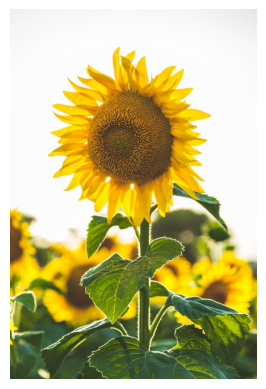

In [11]:
# Load the image in color mode (1 = color, 0 = grayscale, -1 = with alpha channel)
img = cv.imread("data/paul-green-5lRxNLHfZOY-unsplash.jpg", 1) 

# Convert from BGR (OpenCV default) to RGB for correct color display in Matplotlib
img = img[:, :, ::-1]  

# Display the image
plt.imshow(img)
plt.axis("off")  # Hide axes
plt.show()

## Gaussian Noise
Gaussian noise is a type of random noise characterized by a normal distribution, where most pixel intensity variations are small, but extreme variations are possible. It often occurs in images due to sensor limitations or environmental factors.

(-0.5, 639.5, 959.5, -0.5)

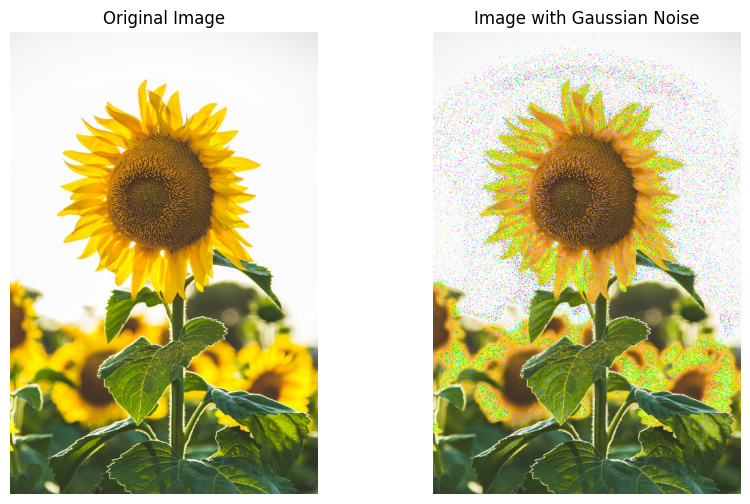

In [12]:
# Add Gaussian noise
mean = 0
variance = 5
sigma = np.sqrt(variance)

# Generate Gaussian noise
gaussian = np.random.normal(mean, sigma, img.shape).astype(np.uint8)

# Add noise and clip values to maintain valid range [0, 255]
noisy_img = np.clip(img + gaussian, 0, 255)

# Display original and noisy images
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes1[0].imshow(img)
axes1[0].set_title('Original Image')
axes1[0].axis('off')
axes1[1].imshow(noisy_img)
axes1[1].set_title('Image with Gaussian Noise')
axes1[1].axis('off')

## Salt-and-Pepper Noise
Salt-and-pepper noise randomly replaces pixel values with either black (0) or white (255), appearing as scattered white and black dots across the image. It is common in images affected by transmission errors or sensor faults.

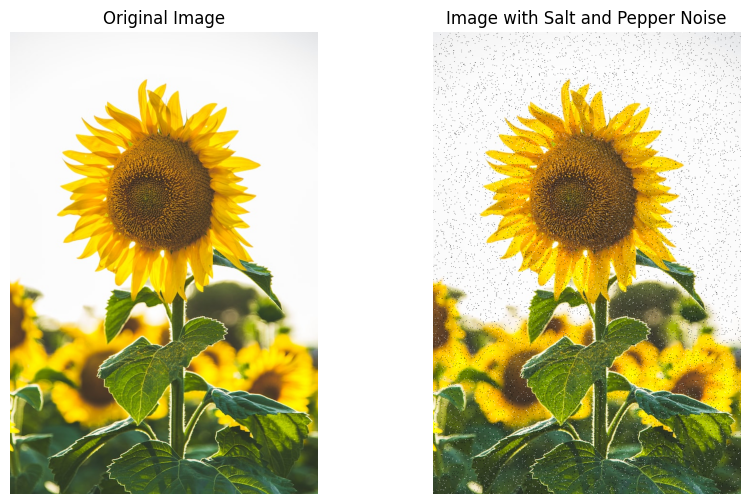

In [13]:
# Add salt and pepper noise
height, width, channels = img.shape
num_pixels = int(0.03 * height * width)  # 3% of image pixels

# Copy image to avoid modifying original
noisy_img2 = img.copy()

# Generate random coordinates
x_coords = np.random.randint(0, width, num_pixels)
y_coords = np.random.randint(0, height, num_pixels)

for x, y in zip(x_coords, y_coords):
    if np.random.rand() < 0.5:
        noisy_img2[y, x] = 0    # Pepper noise (black)
    else:
        noisy_img2[y, x] = 255  # Salt noise (white)

# Display original and salt-and-pepper noisy images
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes2[0].imshow(img)
axes2[0].set_title('Original Image')
axes2[0].axis('off')
axes2[1].imshow(noisy_img2)
axes2[1].set_title('Image with Salt and Pepper Noise')
axes2[1].axis('off')

plt.show()

## Low-Pass Filtering

Low-pass filters smooth an image by averaging pixel values in a local neighborhood, reducing high-frequency noise and preserving general image structures. This filtering technique is essential for noise reduction, but may cause blurring.

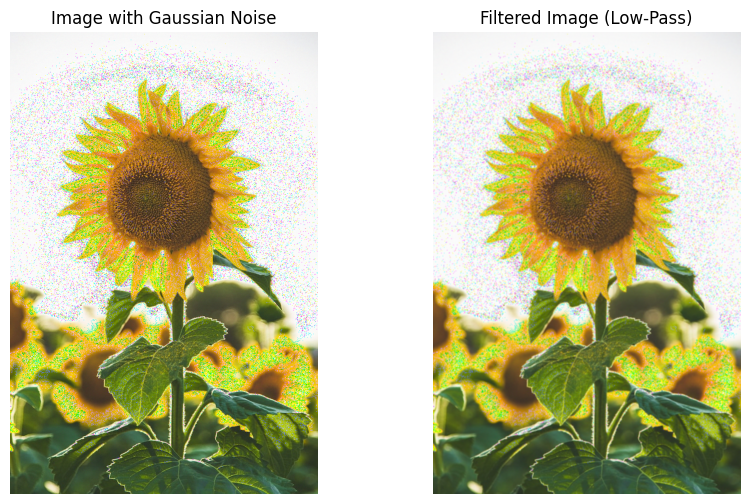

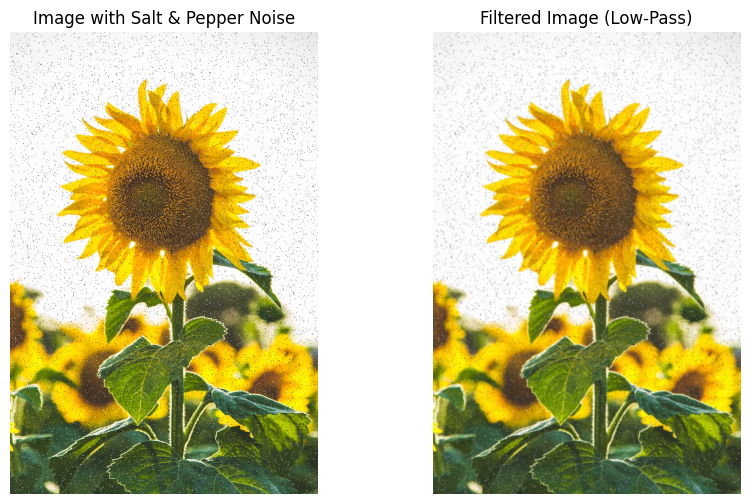

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Define kernel size
kernel_size = 3

# Create a normalized averaging kernel (low-pass filter)
kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)

# Apply the low-pass filter to Gaussian-noised image
flt_img = cv.filter2D(src=noisy_img, ddepth=-1, kernel=kernel)

# Apply the low-pass filter to Salt & Pepper noised image
flt_img2 = cv.filter2D(src=noisy_img2, ddepth=-1, kernel=kernel)

# Display Gaussian noise filtering result
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes1[0].imshow(noisy_img)
axes1[0].set_title('Image with Gaussian Noise')
axes1[0].axis('off')
axes1[1].imshow(flt_img)
axes1[1].set_title('Filtered Image (Low-Pass)')
axes1[1].axis('off')

# Display Salt & Pepper noise filtering result
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes2[0].imshow(noisy_img2)
axes2[0].set_title('Image with Salt & Pepper Noise')
axes2[0].axis('off')
axes2[1].imshow(flt_img2)
axes2[1].set_title('Filtered Image (Low-Pass)')
axes2[1].axis('off')

plt.show()

## High-Pass Filtering
High-pass filters enhance edges and fine details by highlighting areas of rapid intensity change while suppressing uniform regions. It is useful for feature extraction, edge detection, and sharpening images.

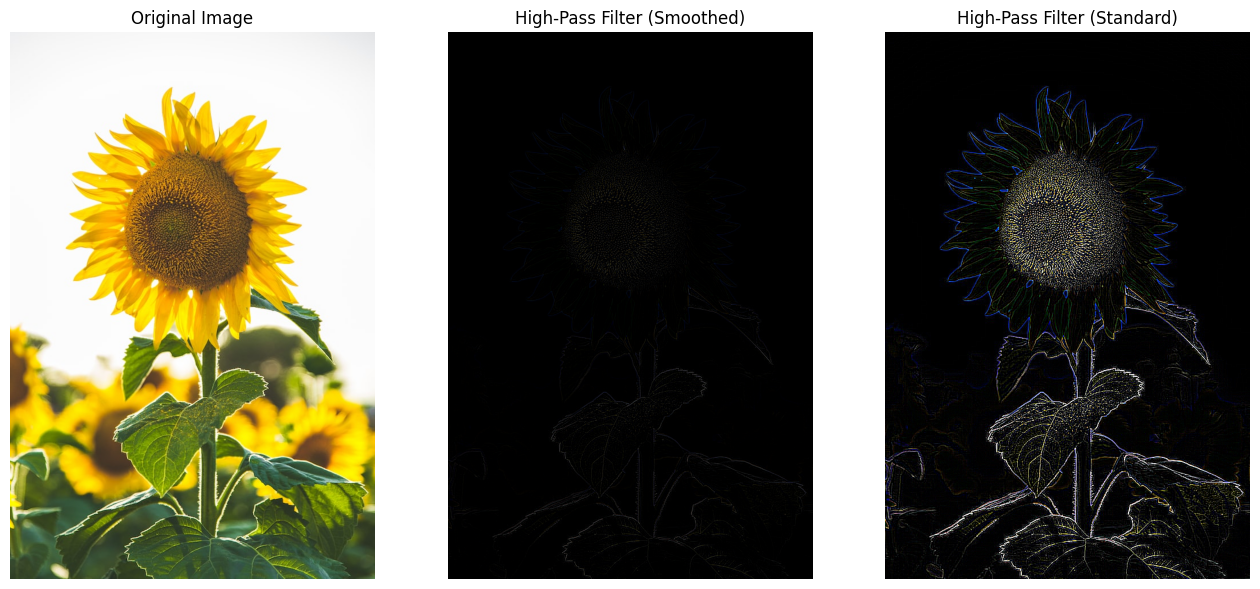

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

# Define high-pass filter kernel (Laplacian-like edge detection)
kernel_hp = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=np.float32)

# Apply high-pass filtering
filtered = cv.filter2D(src=img, ddepth=-1, kernel=kernel_hp)  # Standard high-pass
filtered_moy = cv.filter2D(src=img, ddepth=-1, kernel=kernel_hp / 9)  # Smoothed version

# Display results
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 8))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(filtered_moy)
axes[1].set_title('High-Pass Filter (Smoothed)')
axes[1].axis('off')
axes[2].imshow(filtered)
axes[2].set_title('High-Pass Filter (Standard)')
axes[2].axis('off')

plt.show()

# Median Filtering
Median filtering replaces each pixel with the median value of its local neighborhood, effectively removing isolated noise points without significantly blurring edges.

(-0.5, 639.5, 959.5, -0.5)

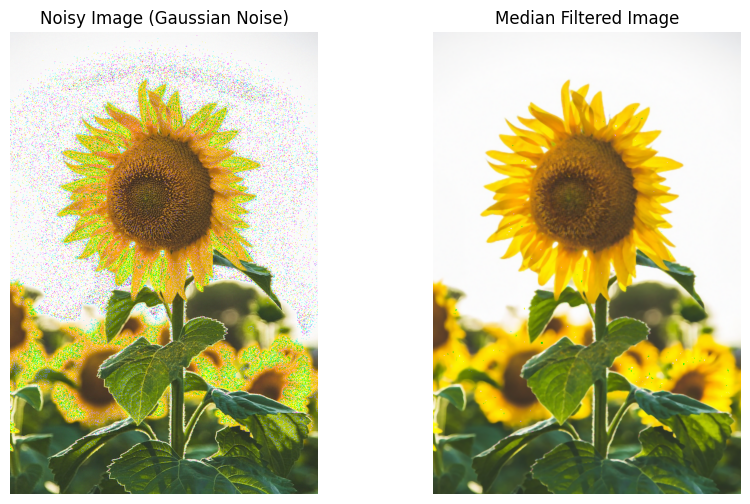

In [37]:
# Gaussian noise reduction
flt_img_median = cv.medianBlur(src=noisy_img, ksize=5) 

# Display Gaussian noise filtering
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes1[0].imshow(noisy_img)
axes1[0].set_title('Noisy Image (Gaussian Noise)')
axes1[0].axis('off')
axes1[1].imshow(flt_img_median)
axes1[1].set_title('Median Filtered Image')
axes1[1].axis('off')

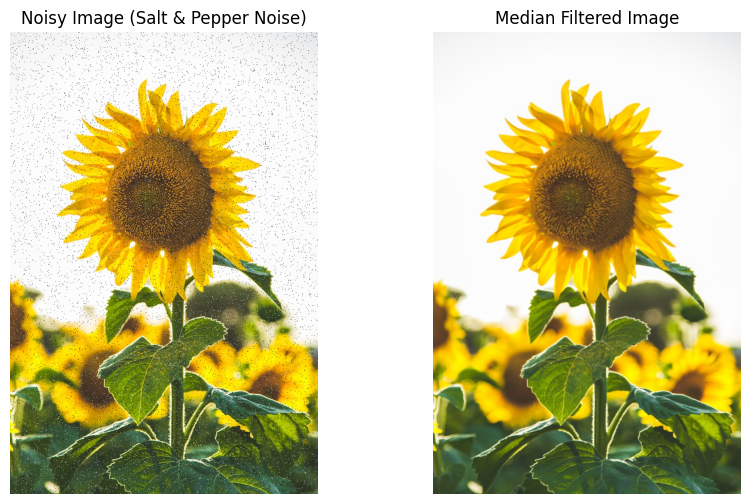

In [38]:
# Salt & Pepper noise reduction
flt_img_median2 = cv.medianBlur(src=noisy_img2, ksize=3) 
# Display Salt & Pepper noise filtering
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes2[0].imshow(noisy_img2)
axes2[0].set_title('Noisy Image (Salt & Pepper Noise)')
axes2[0].axis('off')
axes2[1].imshow(flt_img_median2)
axes2[1].set_title('Median Filtered Image')
axes2[1].axis('off')

plt.show()

## Sharpening Filter
A sharpening filter enhances contrast by emphasizing edges and fine details, making objects appear more distinct.

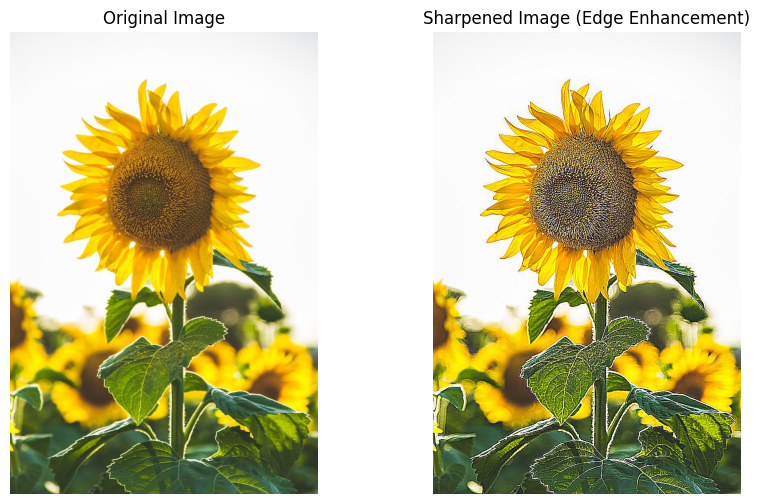

In [40]:
# Sharpening filter kernel
kernel = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1],
], dtype=np.float32)

# Apply sharpening filter
accentuated_img = cv.filter2D(src=img, ddepth=-1, kernel=kernel)

# Display original and sharpened images
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(accentuated_img)
axes[1].set_title('Sharpened Image (Edge Enhancement)')
axes[1].axis('off')

plt.show()

## Morphological Filters (Dilation & Erosion)
Morphological operations modify the structure of an image based on a defined kernel:

- **Erosion** shrinks bright regions, removing small noise and separating objects.
- **Dilation** expands bright regions, filling gaps and connecting nearby objects.

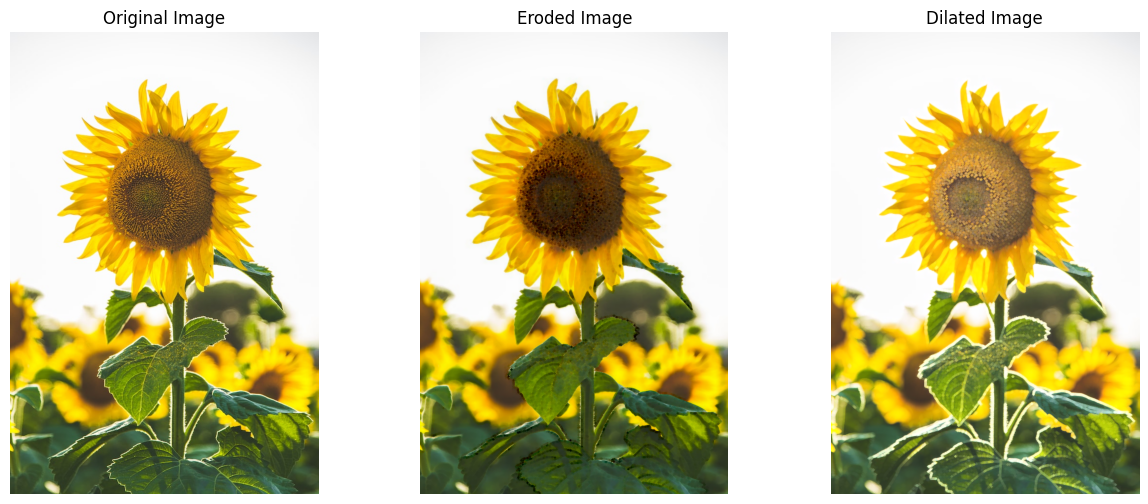

In [41]:
# Define a cross-shaped kernel
kernel = np.array([[0, 1, 0],
                   [1, 1, 1],
                   [0, 1, 0]], np.uint8)

# Apply morphological operations
dilated = cv.dilate(img, kernel, iterations=2)
eroded = cv.erode(img, kernel, iterations=2)

# Display original, eroded, and dilated images
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(eroded)
axes[1].set_title('Eroded Image')
axes[1].axis('off')
axes[2].imshow(dilated)
axes[2].set_title('Dilated Image')
axes[2].axis('off')

plt.show()